In [1]:
import stim
import re
import os
from pyzx import *
import matplotlib.pyplot as plt
import networkx as nx
from pyvis.network import Network

def stim_qasm_comply(qasm: str) -> str:
    q = qasm
    q = re.sub(r'def\s+rx\(qubit q0\)\s*\{[^}]*\}\n+', '', q)
    q = re.sub(r'rx\s*\(\s*q\[(\d+)\]\s*\)\s*;', r'h q[\1];', q)
    q = re.sub(r'reset\s+q\[(\d+)\];', '', q)
    return q



In [2]:
tableau_5_code = stim.Tableau.from_stabilizers([
    stim.PauliString("XZZXI"),
    stim.PauliString("IXZZX"), 
    stim.PauliString("XIXZZ"),
    stim.PauliString("ZXIXZ")
], allow_underconstrained=True)

tableau_bit_code = stim.Tableau.from_stabilizers([
    stim.PauliString("ZZ_"),
    stim.PauliString("_ZZ"),
], allow_underconstrained=True)

# print(tableau_bit_code)
print(tableau_5_code)

k = 2
n = 5

stabilizers = []

for i in range (n - k):
    stabilizers.append(stim.PauliString(f"Z{i}") * stim.PauliString(n+k))

for i in range(n-k, n): 
    stabilizers.append(stim.PauliString(f"Z{i}*Z{i+k}") * stim.PauliString(n+k)) 
    stabilizers.append(stim.PauliString(f"X{i}*X{i+k}") * stim.PauliString(n+k)) 

# stabilizers.append(stim.PauliString("I" * (out - input))  + stim.PauliString("X" * 2*input))

print("Stabilizers:")
for s in stabilizers:
    print(s)

# tableau = stim.Tableau.from_stabilizers(stabilizers)

state = stim.TableauSimulator()
state.set_state_from_stabilizers(stabilizers)
state.do_tableau(tableau_5_code, range(n))

print(state.current_inverse_tableau().inverse())
t = state.current_inverse_tableau().inverse()

qasm = t.to_circuit(method="graph_state").to_qasm(open_qasm_version=3)

# print(tableau_5_code)
pyzx_circ = Circuit.from_qasm(stim_qasm_comply(qasm))
# draw(pyzx_circ  )
g = pyzx_circ.to_graph()
input_state = "0"*(n+k)
# draw(g, labels=True)
inputs = g.outputs()[n:n+k]
outputs = g.outputs()[:n]
g.apply_state(input_state)
# clifford_simp(g)
# g.normalize()
# g.auto_detect_io()
# draw(g, labels=True )

# draw(g, labels=True)
# c = Circuit.from_graph(g)

# draw(c)


t0 = tensorfy(g)
# g = GraphState(g)
t1 = tensorfy(g)
# g.to_canonical_form()
t2 = tensorfy(g)

compare_tensors(t0, t2)

d = to_universal_graph_representation(g, inputs, outputs)
# print(t0)

+-xz-xz-xz-xz-xz-
| -+ ++ -+ ++ --
| _X __ ZX _Z Z_
| _Z _X __ ZX _Z
| XZ _Z XX __ XX
| _X _Z _Z _X XZ
| Z_ ZX ZZ ZZ __
Stabilizers:
+Z______
+_Z_____
+__Z____
+___Z_Z_
+___X_X_
+____Z_Z
+____X_X
+-xz-xz-xz-xz-xz-xz-xz-
| -+ ++ -+ ++ ++ -- +-
| _X __ ZX _Z __ Z_ _Z
| _Z _X __ ZX _Z _Z __
| XZ _Z XX __ __ XX _X
| _X _Z _Z _X __ XZ _X
| Z_ ZX ZZ ZZ _Z __ __
| __ __ __ _Z ZX __ __
| __ __ __ __ __ _Z ZX


In [3]:

qasm_5qubit = tableau_5_code.to_circuit(method="elimination").to_qasm(open_qasm_version=3)

qasm_bit = tableau_bit_code = stim.Tableau.from_stabilizers([
    stim.PauliString("ZZ_"),
    stim.PauliString("_ZZ"),
], allow_underconstrained=True).to_circuit(method="elimination").to_qasm(open_qasm_version=3)

pyzx_circ = Circuit.from_qasm(qasm_5qubit)
g = pyzx_circ.to_graph()
input_state = "0"*(3) + "/"*2
g.apply_state(input_state)


g.auto_detect_io()

g = GraphState(g)
s1 = tensorfy(g)
# draw(g, labels=True )
# draw(g, labels=True)


g.to_canonical_form()
# g = g.state_to_map()
s2 = tensorfy(g)
# print(t2)
compare_tensors(t2, s2, preserve_scalar=False)

True

In [4]:

qasm_5qubit = stim.Tableau.from_stabilizers([
    stim.PauliString("XZZXI"),
    stim.PauliString("IXZZX"), 
    stim.PauliString("XIXZZ"),
    stim.PauliString("ZXIXZ")
], allow_underconstrained=True).to_circuit(method="elimination").to_qasm(open_qasm_version=3)

shor_code = stim.Tableau.from_stabilizers([
    stim.PauliString("ZZIIIIIII"),
    stim.PauliString("ZIZIIIIII"),
    stim.PauliString("IIIZZIIII"),
    stim.PauliString("IIIZIZIII"),
    stim.PauliString("IIIIIIZZI"),
    stim.PauliString("IIIIIIZIZ"),
    stim.PauliString("XXXXXXIII"),
    stim.PauliString("IIIXXXXXX"),
], allow_underconstrained=True).to_circuit().to_qasm(open_qasm_version=3)

qasm_7qubit = stim.Tableau.from_stabilizers([
    stim.PauliString("IIIXXXX"),
    stim.PauliString("IXXIIXX"),
    stim.PauliString("XIXIXIX"),
    stim.PauliString("IIIZZZZ"),
    stim.PauliString("IZZIIZZ"),
    stim.PauliString("ZIZIZIZ")
], allow_underconstrained=True).to_circuit().to_qasm(open_qasm_version=3) 


In [5]:

pyzx_circ = Circuit.from_qasm(qasm_5qubit)
g = pyzx_circ.to_graph()
input_state = "0"*(4) + "/"*1
g.apply_state(input_state)
d = to_universal_graph_representation(g)

TypeError: to_universal_graph_representation() missing 2 required positional arguments: 'inputs' and 'outputs'

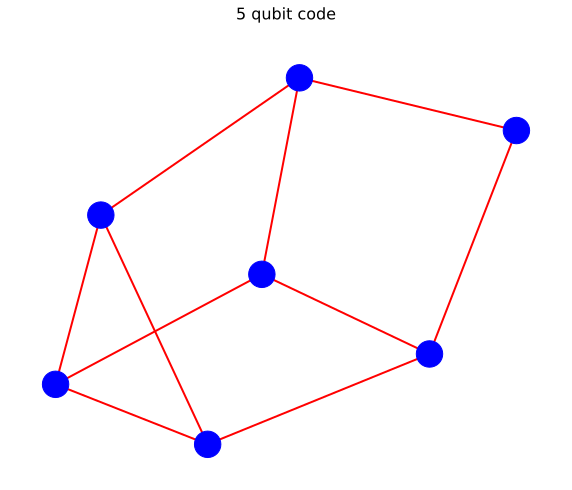

In [6]:
nxg = nx.Graph()
bounds = []
for v in d["vertices"]:
    v_type = v["t"]
    if v["id"] in d["inputs"]:
        color = "green"
    else:
        color = "blue"
    if v_type != VertexType.BOUNDARY:
        nxg.add_node(v["id"], 
                    color=color, 
                    title=f"Type: {v_type.name}")
    else:
        bounds.append(v["id"])
        
for e in d["edges"]:
    vertexes = d["vertices"]
    edge_type = e[2]
    edge_color = "red" if edge_type == EdgeType.HADAMARD else "black"
    if e[0] not in bounds and e[1] not in bounds:
        nxg.add_edge(e[0], e[1])
        nxg[e[0]][e[1]]['color'] = edge_color

pos = nx.spring_layout(nxg, seed=42)  # nice spacing

node_colors = [nxg.nodes[n]['color'] for n in nxg.nodes()]
edge_colors = [nxg[u][v]['color'] for u,v in nxg.edges()]

# Draw the graph
plt.figure(figsize=(10,8))
nx.draw_networkx_nodes(nxg, pos, node_color=node_colors, node_size=700)
nx.draw_networkx_edges(nxg, pos, edge_color=edge_colors, width=2)
# nx.draw_networkx_labels(nxg, pos, font_size=10, font_color='white')

# Add title to the plot
plt.title("5 qubit code", fontsize=16, pad=20)

plt.axis('off')
plt.show()

net = Network(notebook=True, directed=False)
net.from_nx(nxg)
